# Exploring LangGraph's Basics
This Jupyter Notebook is all about testing the setup and exploring the basic features of LangGraph. Each block of code is dedicated to a short exercise introducing different parts of the LangGraph library.

This first one purely checks wether the setup works: presence of the python kernel through miniconda and existence of a working API connection to Antrophic.

In [ ]:
from dotenv import load_dotenv
load_dotenv(override=True)  # Force loading environment variables from .env file

from langchain_anthropic import ChatAnthropic

# This block was used for debugging environment variables
import os 
print(os.getcwd())
val = os.environ.get("ANTHROPIC_API_KEY")
print("present:", val is not None, "| starts with:", (val or "")[:11])

# Testing the API to Antrophic's Claude model
llm = ChatAnthropic(model="claude-sonnet-5")
response = llm.invoke("Say hello in one short sentence.")
print(response.content)

c:\Users\hemin\GitHub_repos\agent-learning-lab\05-agentic-ecosystem-architectures\B-langgraph\weather-multi-agent
present: True | starts with: sk-ant-api0
Hello! Hope you're having a great day.


## Hello Graph

The point of this step is purely `StateGraph` → `add_node` → `set_entry/finish_point` → `compile` → `invoke`.

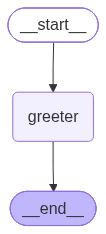

'Hey Bob, how is your day going?'

In [6]:
from typing import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict): # our state schema
    message: str

def greeting_node(state: AgentState) -> AgentState: # need to pass in and out the state to maintain context
    """Simple node that adds a greeting to the message to the state."""
    state["message"] = "Hey " + state["message"] + ", how is your day going?"
    return state


graph = StateGraph(AgentState)
graph.add_node("greeter", greeting_node)
graph.set_entry_point("greeter") # entry point and connected node
graph.set_finish_point("greeter")

app = graph.compile()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

result = app.invoke({"message": "Bob"})
result["message"]

## Multiple Input Graph
A graph whose state has multiple inputs is observed. Given a list of integers and one of the operations `+`or `*`, it is executed on all elements of the list and returned.

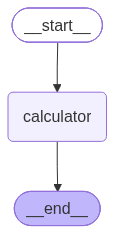

Your product is equal to 24


In [46]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    values: List[int]
    operation: str
    result: str # cannot use this variable below since not in input, but can assign it

def addORmultiply_node(state: AgentState) -> AgentState:
    """This function handles different inputs."""
    if state["operation"] == "*":
        if len(state["values"]) == 0:
            state["result"] = f"Your list does not contain any integers."
        else:
            temp = 1
            for i in range (0,len(state["values"])):
                temp *= state["values"][i]
            state["result"] = f"Your product is equal to {temp}"
    elif state["operation"] == "+":
        if len(state["values"]) == 0:
            state["result"] = f"Your list does not contain any integers."
        else:
            state["result"] = f"Your sum is equal to {sum(state["values"])}"
    else:
        state["result"] = f"Please try again with one of the operations * or +."
    return state

graph = StateGraph(AgentState)
graph.add_node("calculator", addORmultiply_node)
graph.set_entry_point("calculator") # entry point and connected node
graph.set_finish_point("calculator")

app = graph.compile()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

answer = app.invoke({"values": [4,3,2], "operation": "*"})
print(answer["result"])

## Sequential Graph
Create multiple connected nodes that process and upgrade different parts of the state. One node adds the name, another the age and the last one a list of skills to the result. Also, this time the `START` and `END` nodes are used for convenience.

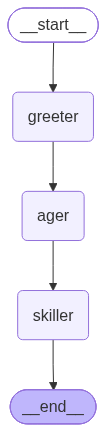

Luka, welcome to the system! You are 25 years old. You have skills in: n8n, Codex, Claude Code, and in the future also LangGraph.


In [52]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
    name: str
    age: int
    skills: List[str]
    result: str

def greeting_node(state: AgentState) -> AgentState:
    """Adds a personalized greeting to the result."""
    state["result"] = f"{state["name"]}, welcome to the system! "
    return state

def mention_age_node(state: AgentState) -> AgentState:
    """Adds the age to the result."""
    state["result"] += f"You are {state["age"]} years old. "
    return state

def listing_skills_node(state: AgentState) -> AgentState:
    """Lists all skills at the end."""
    state["result"] += f"You have skills in:"
    for i in range (0,len(state["skills"])):
        if i != len(state["skills"])-1:
            state["result"] += f" {state["skills"][i]},"
        else:
            state["result"] += f" and {state["skills"][i]}."
    return state

graph = StateGraph(AgentState)
graph.add_node("greeter", greeting_node)
graph.add_node("ager", mention_age_node)
graph.add_node("skiller", listing_skills_node)
graph.add_edge(START, "greeter")
graph.add_edge("greeter", "ager")
graph.add_edge("ager","skiller")
graph.add_edge("skiller", END)

app = graph.compile()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

answer = app.invoke({"name": "Luka", "age": 25, "skills": ["n8n", "Codex", "Claude Code", "in the future also LangGraph"]})
print(answer["result"])

## Conditional Graph
Implement conditional logic to route the flow: conditional edges and router node. Given a `+` or `-` sign, the input numbers are decided to be added or subtracted.

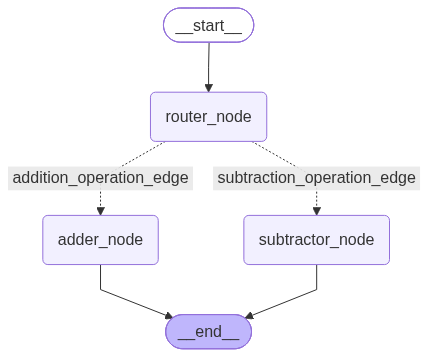

1
8


In [62]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    result: int

def adder(state: AgentState) -> AgentState:
    """This node adds 2 numbers."""
    state["result"] = state["number1"] + state["number2"]
    return state

def subtractor(state: AgentState) -> AgentState:
    """This node subtracts 2 numbers."""
    state["result"] = state["number1"] - state["number2"]
    return state

def router(state: AgentState) -> AgentState:
    """This node will select the next node of the graph."""
    if state["operation"] == "+":
        return "addition_operation_edge" # the edge name that should follow: not return the state!
    if state["operation"] == "-":
        return "subtraction_operation_edge"

graph = StateGraph(AgentState)
graph.add_node("adder_node", adder)
graph.add_node("subtractor_node", subtractor)
graph.add_node("router_node", lambda state:state) # Input state will be output as nothing changed and not returned in function; lambda function takes role of passthrough
graph.add_edge(START, "router_node")
graph.add_conditional_edges("router_node", router, {"addition_operation_edge": "adder_node", "subtraction_operation_edge": "subtractor_node"}) # From router_node with decision function implement path map, i.e. the two also above used edges any to which nodes they go
graph.add_edge("adder_node", END)
graph.add_edge("subtractor_node", END)

app = graph.compile()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

answer = app.invoke({"number1": 4, "operation": "-", "number2": 3})
print(answer["result"])

input = AgentState(number1 = 7, operation = "+", number2 = 1)
print(app.invoke(input)["result"])

## Looping Graph
Implement looping logic and controlling graph flow. The loop here could be realized by a for loop, but that's not the point. And it could be done differently in LangGraph apparently.

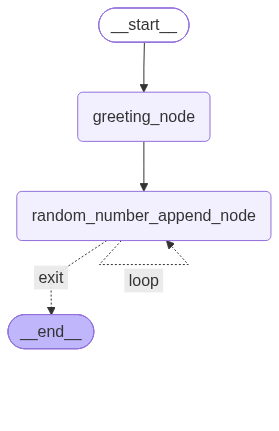

Hi there, Luka! Your three randomly generated numbers from 0 to 10 are [8, 10, 0]!


In [73]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
import random

class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int

def greeter(state: AgentState) -> AgentState:
    """Adds a personalized greeting in the beginning."""
    state["name"] = f"Hi there, {state["name"]}!"
    state["counter"] = 0 # overrides user input for robustness
    state["number"] = []
    return state

def random_fct(state: AgentState) -> AgentState:
    """Generates a ramdom number from 1 to 10 and appends to list."""
    state["number"].append(random.randint(0,10))
    state["counter"] += 1
    return state 

def continue_reasoning(state:AgentState) -> AgentState:
    """Function to decide what to do next."""
    if state["counter"] < 3:
        #print("ENTERING LOOP ", state["counter"])
        return "loop" # Continue looping
    else: 
        return "exit"

graph = StateGraph(AgentState)
graph.add_node("greeting_node", greeter)
graph.add_node("random_number_append_node", random_fct)
graph.add_edge(START, "greeting_node")
graph.add_edge("greeting_node", "random_number_append_node")
graph.add_conditional_edges(
    "random_number_append_node",
    continue_reasoning,
    {
        "loop" : "random_number_append_node",
        "exit": END
    }
)

app = graph.compile()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

input = AgentState(name = "Luka")
answer = app.invoke(input)
print(f"{answer["name"]} Your three randomly generated numbers from 0 to 10 are {answer["number"]}!")

## Graph Including LLM
A basic Graph is created which involves a node processing a `HumanMessage` (via standard input) by an LLM. This interaction is the main point of this reduced exercise, so just a simple bot is constructed.

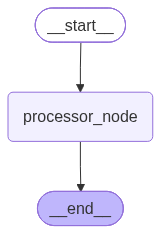


AI: Hallo! Wie kann ich dir heute helfen?

AI: Hallo Bob! Schön, dich kennenzulernen. Wie kann ich dir heute helfen?

AI: Das weiß ich leider nicht – ich habe keinen Zugriff auf Informationen über dich, es sei denn, du sagst mir deinen Namen selbst. Wie heißt du denn? 😊


In [13]:
from typing import TypedDict, List
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from dotenv import load_dotenv

load_dotenv(override=True)  # Force loading environment variables from .env file
llm = ChatAnthropic(model="claude-sonnet-5")

class AgentState(TypedDict):
    messages: List[HumanMessage]

def process_messages_to_llm(state: AgentState) -> AgentState:
    response = llm.invoke(state["messages"])
    print(f"\nAI: {response.text}")
    return state

graph = StateGraph(AgentState)
graph.add_node("processor_node", process_messages_to_llm)
graph.add_edge(START, "processor_node")
graph.add_edge("processor_node", END)

agent = graph.compile()
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

user_input = input("Talk to a mindless AI: ") # In VSCode the Quick-access on to top pops up for the input
#agent.invoke({"messages": [HumanMessage(content=user_input)]})
while user_input != "exit":
    agent.invoke({"messages": [HumanMessage(content=user_input)]}) # Note that sometimes the AI message is not extracted correctly
    user_input = input("Talk to a mindless AI: ")

## Chatbot with Conversation History
Create a form of memory in the state via `HumanMessage`, `AIMessage` and `Union`.

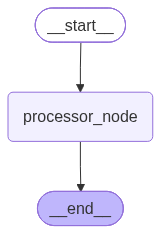


AI: Hello! How can I help you today?
CURRENT STATE:  [HumanMessage(content='hello', additional_kwargs={}, response_metadata={}), AIMessage(content=[{'signature': 'Es0CCpABCBIYAipA69BeC5M/445gh6M4qVZGstWclnKj6k9oL3BPVxz2sNDjyAukd9RT8wDmZh0/byP3L81gITLIICXN5FmaMqiUKjIPY2xhdWRlLXNvbm5ldC01OABCCHRoaW5raW5nWiQzN2Q0NjcwOC00MmQzLTQ1MzgtODMxMS04YjYzZmIxYTgxYTCoAb3D7tUGEgxqn0IjfwES7f0mooQaDIkme8x3KZljCkAXSiIweKhQisGx+Tonby3u5CyV4nmfNGQSmHx0suY0V8+B20p+UxdjZt2O42hLl/3CfWupKmp6RVcl9Lv7BVfmdX4SpXaeampHyNy+4w+bGQmfbW32+tmQDaodMTYAZ0lCXQfim8oUfslSqqNG+CxiMg4JEEXgAZF5bAmmv5y5eNptsMAVQzm8IwpFPTtMrfn6FJ3e5HqzSU1TJskKF/WpGAE=', 'thinking': '', 'type': 'thinking'}, {'text': 'Hello! How can I help you today?', 'type': 'text'}], additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]
[HumanMessage(content='hello', additional_kwargs={}, response_metadata={}), AIMessage(content=[{'signature': 'Es0CCpABCBIYAipA69BeC5M/445gh6M4qVZGstWclnKj6k9oL3BPVxz2sNDjyAukd9RT8wDmZh0/byP3L81gITLI

In [ ]:
from typing import TypedDict, List, Union
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from dotenv import load_dotenv

load_dotenv(override=True)  # Force loading environment variables from .env file
llm = ChatAnthropic(model="claude-sonnet-5")

class AgentState(TypedDict):
    messages: List[Union[HumanMessage, AIMessage]] # Union allows for both data types to be stored in the messages list
    #messages_ai: List[AIMessage]   would work some way if that is added to the messages: List[HumanMessage] from before

def process_messages_to_llm(state: AgentState) -> AgentState:
    """This node will solve the request you input."""
    response = llm.invoke(state["messages"])
    state["messages"].append(AIMessage(content=response.content))
    print(f"\nAI: {response.text}")
    print("CURRENT STATE: ", state["messages"])
    return state

graph = StateGraph(AgentState)
graph.add_node("processor_node", process_messages_to_llm)
graph.add_edge(START, "processor_node")
graph.add_edge("processor_node", END)

agent = graph.compile()
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

conversation_history = []
user_input = input("Talk to a mindful AI: ") # In VSCode the Quick-access on to top pops up for the input
while user_input != "exit": # But user exit also wipes out data, so should save it in database or text file for testing purposes
    conversation_history.append(HumanMessage(content=user_input))
    result = agent.invoke({"messages": conversation_history})

    print(result["messages"])
    conversation_history = result["messages"]

    user_input = input("Talk to a mindless AI: ")

# Saving conversation_history in text file
with open("simplest_chatbot.txt", "w") as file:
    file.write("Your conversation Log:\n")
    for message in conversation_history:
        if isinstance(message, HumanMessage):
            file.write(f"You: {message.content}\n")
        elif isinstance(message, AIMessage):
            file.write(f"AI: {message.text}\n\n")
    file.write("End of conversation.\n")
print("Conversation saved to simplest_chatbot.txt.")

## ReAct Agent
This example explores `Tools` and working with different types of messages, including `SystemMessage` for a system prompt for the agent. The graph is START -> AgentNode -> Loop with ToolNode -> Exit from AgentNode to END at some point. Compared to an explicit router example as in "Conditional Graph", here the LLM node decides on its own wether a tool and which tool is called, using `bind_tools()`.

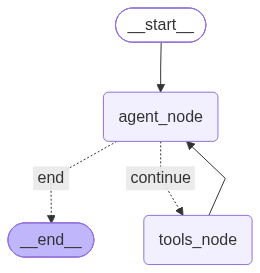

================================ Human Message =================================

Add 5 + 7, then multiply by 10 and finally subtract 4. Tell me a joke.
content=[{'signature': 'EtwDCqQBCBIYAipAxc39CLPl9MkFpAGlnMRIXL93Yeukv/bfBYd5DOoqoDhkpxn6qLW7Q8Qb414/idzkIa/2pH+HfRQ8fazPhopmmTIPY2xhdWRlLXNvbm5ldC01OABCCHRoaW5raW5nWiQzN2Q0NjcwOC00MmQzLTQ1MzgtODMxMS04YjYzZmIxYTgxYTCaAREKD2NsYXVkZS1zb25uZXQtNagBztPz1QYSDNX2k/0tNjI5mPtA+RoM443jUyEFqwoHn9ElIjBNHE5UyB4xxZT7Ta6XwdA/QVGFWTyB2kz9xtG3XyNHUxo8nSQsnyth3mvHEJdf/uIq5AFh/vANScGa4X1KN8OTFXNeCQWyQ2KFUj3LUGO/z9bW8LWVvAb3GlkuD6L+/zXWXRw8uLGD8XASKNkTZlZd1vdysIlkbAaHqdnoIpDxi5lFHFrr0B/z29G6DwJmLYHkiGgsXcJgd0+buzTh3lDiLEiw/gUAiPM18hhn7lg0xfq70VDV2LKHIWRT11JL9pcwNgK2z3LMZVZZAnoywtjDa6ewYKYpNp7nwi0cuU4g3DS0yNiStd1bv6d7ffKpmF3crmG4l7XtEuihouwgYZ74thz8+ydq2q+85f/9sH/tKsA+Ssjo53sYAQ==', 'thinking': '', 'type': 'thinking'}, {'text': "I'll start by adding 5 + 7 first, since the next step depends on that result.", 'type': 'text'}, {'id': 'toolu_01CzML5CnFHBd6zmKw

In [ ]:
from typing import TypedDict, Annotated, Sequence # Annotated provides context without affecting the type itself; Sequence automatically handles the state updates for sequences such as by adding new messages to the chat history
from langchain_core.messages import BaseMessage, ToolMessage, SystemMessage # BM: foundational class for all types in LangGraph (Parent class of AIMessage, HumanMessage, ToolMessage,...); TM: Passes data back to LLM after it calls a tool; SM: Providing instructions to LLM
from langchain_core.tools import tool
from langgraph.graph.message import add_messages # Reducer function: Rule that controls how updates from nodes are combined with the existing state, i.e. tells us how to merge new data into the current state instead of replacing value entirely
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from dotenv import load_dotenv

load_dotenv(override=True)  # Force loading environment variables from .env file


class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages] # Reducer function preserves state by appending new messages; Sequence of BaseMessages is datatype and add_message provides metadata, therefore have Annotated

@tool # decorator: here, prebuilt function that takes the add function and returns another function
def add(a: int, b: int):
    """This is an addition function that adds 2 numbers together.""" # mandatory telling the LLM about the purpose of this tool
    return a + b

@tool
def multiply(a: int, b: int):
    """This is a multiplication function that multiplies 2 numbers.""" 
    return a * b

tools = [add, multiply]
llm = ChatAnthropic(model="claude-sonnet-5").bind_tools(tools)

def model_call(state: AgentState) -> AgentState:
    #response = llm.invoke(["You are my AI assistant, please answer my query to the best of your ability."] + state["messages"]) # Same as two lines below
    system_prompt = SystemMessage(content="You are my AI assistant, please answer my query to the best of your ability.") # works also if content="""..."""
    response = llm.invoke([system_prompt] + state["messages"]) # with state["messages"] adding the HumanMessage query
    return {"messages": [response]} # compact way of updating the state; reducer function handles appending of message

def continue_ReAct(state: AgentState):
    messages = state["messages"]
    last_message = messages[-1]
    print(last_message)
    if not last_message.tool_calls:
        return "end"
    else:
        return "continue"


graph = StateGraph(AgentState)
graph.add_node("agent_node", model_call)
tool_node = ToolNode(tools=tools)
graph.add_node("tools_node", tool_node)

graph.add_edge(START, "agent_node")
graph.add_conditional_edges(
    "agent_node",
    continue_ReAct,
    {
        "continue": "tools_node",
        "end": END,
    },
)
graph.add_edge("tools_node", "agent_node") # get back to agent

agent = graph.compile()
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))


# Now for a structured output use stream. But this also means that agent is not invoked but called via stream.

def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()


inputs = {"messages": [("user", "Add 5 + 7, then multiply by 10 and finally subtract 4. Tell me a joke.")]}
print_stream(agent.stream(inputs, stream_mode="values"))

## Draft Agent
Establish a similar agentic structure as above but with conditional edge placed at the tools node and not the agent. In particular, the agent cannot keep up the conversation infinitely since the agent does not know that as soon as the document is saved, the tools node processing this will end the process. Above, the agent could have continued to make random tool requests to keep the conversation alive.

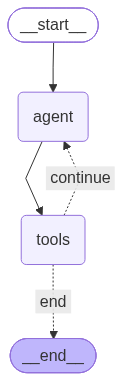


 ===== DRAFTER =====

🤖 AI: I'd love to help you create a document! Since this is a fresh start, could you let me know a bit more about what you have in mind? For example:

- **What type of document** are you working on? (e.g., a letter, essay, report, story, memo, resume, blog post, etc.)
- **What's the topic or purpose**? What should it be about or accomplish?
- **Any specific content, tone, or structure** you already have in mind?

Once you give me a starting point, I can draft the initial content and we can refine it together from there!

👤 USER: Write an email

🤖 AI: I'd be happy to help you write an email! To get started, could you tell me a few details:

1. **Who is this email for?** (e.g., a colleague, client, friend, potential employer)
2. **What's the purpose?** (e.g., following up, requesting information, apologizing, introducing yourself, thanking someone)
3. **Tone?** (formal, casual, friendly, professional)
4. **Any key points** you want to include?

If you're not sure y

In [ ]:
from typing import TypedDict, Annotated, Sequence # Annotated provides context without affecting the type itself; Sequence automatically handles the state updates for sequences such as by adding new messages to the chat history
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage, SystemMessage # BM: foundational class for all types in LangGraph (Parent class of AIMessage, HumanMessage, ToolMessage,...); TM: Passes data back to LLM after it calls a tool; SM: Providing instructions to LLM
from langchain_core.tools import tool
from langgraph.graph.message import add_messages # Reducer function: Rule that controls how updates from nodes are combined with the existing state, i.e. tells us how to merge new data into the current state instead of replacing value entirely
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from dotenv import load_dotenv

load_dotenv(override=True)  # Force loading environment variables from .env file

# This is the global variable to store document content
document_content = ""

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


@tool
def update(content: str) -> str:
    """Updates the document with the provided content."""
    global document_content
    document_content = content
    return f"Document has been updated successfully! The current content is:\n{document_content}"


@tool
def save(filename: str) -> str:
    """Save the current document to a text file and finish the process.
    
    Args:
        filename: Name for the text file.
    """

    global document_content

    if not filename.endswith('.txt'):
        filename = f"{filename}.txt"


    try:
        with open(filename, 'w') as file:
            file.write(document_content)
        print(f"\n💾 Document has been saved to: {filename}")
        return f"Document has been saved successfully to '{filename}'."
    
    except Exception as e:
        return f"Error saving document: {str(e)}"
    

tools = [update, save]

llm = ChatAnthropic(model="claude-sonnet-5").bind_tools(tools)

def our_agent(state: AgentState) -> AgentState:
    system_prompt = SystemMessage(content=f"""
    You are Drafter, a helpful writing assistant. You are going to help the user update and modify documents.
    
    - If the user wants to update or modify content, use the 'update' tool with the complete updated content.
    - If the user wants to save and finish, you need to use the 'save' tool.
    - Make sure to always show the current document state after modifications.
    
    The current document content is:{document_content}
    """)

    if not state["messages"]:
        user_input = "I'm ready to help you update a document. What would you like to create?"
        user_message = HumanMessage(content=user_input)

    else:
        user_input = input("\nWhat would you like to do with the document? ")
        print(f"\n👤 USER: {user_input}")
        user_message = HumanMessage(content=user_input)

    all_messages = [system_prompt] + list(state["messages"]) + [user_message]

    response = llm.invoke(all_messages)

    print(f"\n🤖 AI: {response.text}")
    if hasattr(response, "tool_calls") and response.tool_calls:
        print(f"🔧 USING TOOLS: {[tc['name'] for tc in response.tool_calls]}")

    return {"messages": list(state["messages"]) + [user_message, response]}


def should_continue(state: AgentState) -> str:
    """Determine if we should continue or end the conversation."""

    messages = state["messages"]
    
    if not messages:
        return "continue"
    
    # This looks for the most recent tool message....
    for message in reversed(messages):
        # ... and checks if this is a ToolMessage resulting from save
        if (isinstance(message, ToolMessage) and 
            "saved" in message.content.lower() and
            "document" in message.content.lower()):
            return "end" # goes to the end edge which leads to the endpoint
        
    return "continue"

def print_messages(messages):
    """Function I made to print the messages in a more readable format"""
    if not messages:
        return
    
    for message in messages[-3:]:
        if isinstance(message, ToolMessage):
            print(f"\n🛠️ TOOL RESULT: {message.content}")


graph = StateGraph(AgentState)

graph.add_node("agent", our_agent)
graph.add_node("tools", ToolNode(tools))

graph.set_entry_point("agent")

graph.add_edge("agent", "tools")


graph.add_conditional_edges(
    "tools",
    should_continue,
    {
        "continue": "agent",
        "end": END,
    },
)

agent = graph.compile()
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

def run_document_agent():
    print("\n ===== DRAFTER =====")
    
    state = {"messages": []}
    
    for step in agent.stream(state, stream_mode="values"):
        if "messages" in step:
            print_messages(step["messages"])
    
    print("\n ===== DRAFTER FINISHED =====")

if __name__ == "__main__":
    run_document_agent()

## RAG Agent
Load a PDF with `PyPDFLoader`, use the `RecursiveCharacterTextSplitter` to split the document into chunks and use a compatible embedding model to load the chunks into a vector store like `Chroma`. Define a retriever to create a `retriever_tool` which can be used by a `retriever_agent` who is supervised by a `supervisor_agent`. The agentic structure, graph implementation and running the agents is similar to above - the main new part here is processing the PDF.